In [15]:
import os
import cv2
import numpy as np
import pytesseract
from glob import glob
from fpdf import FPDF
from PIL import Image
from scipy.signal import find_peaks
from matplotlib import pyplot as plt

# Functions

In [3]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def showimg(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img_rgb)
    plt.title("Image")
    plt.axis("off")
    plt.show()        

In [34]:
def extract_using_peaks(video_path, video_name, scores, save_dir = "__pages__"):
    save_path = os.path.join(save_dir, video_name)
    create_dir(save_path)
    peaks, _ = find_peaks(scores, height=np.mean(scores)+2*np.std(scores))

    cap = cv2.VideoCapture(video_path)
    frames = []
    idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx in peaks:
            cv2.imwrite(os.path.join(save_path, f"page_{len(frames)}.png"), frame)
            frames.append(frame)

        idx += 1

    cap.release()
    print(f"{video_name}: {len(frames)} pages")

In [35]:
def extract_pages(video_path, video_name, threshold, save_dir = "__pages__"):
    
    name      = os.path.splitext(os.path.basename(video_path))[0]
    save_path = os.path.join(save_dir, name)
    create_dir(save_path)

    cap = cv2.VideoCapture(video_path)

    prev_gray = None
    prev_img = None
    page_count = 0
    frame_idx = 0
    save_next_change = False

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_gray is None:
            cv2.imwrite(os.path.join(save_path, f"page_{page_count}.png"), frame)
            page_count += 1
            prev_gray = gray
            prev_img = frame
            continue

        diff = cv2.absdiff(prev_gray, gray)
        score = diff.mean()

        if score > threshold:

            if(save_next_change):
                cv2.imwrite(os.path.join(save_path, f"tpage_{page_count}.png"), prev_img)
                save_next_change = False
            else :
                save_next_change = True
            
            prev_img = frame
            page_count += 1
            prev_gray = gray
              
        frame_idx += 1

    cap.release()
    print(f"Extracted {page_count} pages")

In [36]:
def get_scores(video_path):
    cap = cv2.VideoCapture(video_path)
    prev = None
    scores = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev is not None:
            scores.append(cv2.absdiff(prev, gray).mean())

        prev = gray

    cap.release()
    return scores

### get the video from storage and analyse the page difference

In [37]:
videos_path = glob("videos/*")
video_name = None
stat_array = []

In [38]:
for video_path in videos_path:
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    print(f"\nAnalyzing: {video_name}")

    stat_array = get_scores(video_path)

    mean = np.mean(stat_array)
    median = np.median(stat_array)
    std = np.std(stat_array)
    max_val = np.max(stat_array)

    # Auto threshold
    mean_std_threshold = mean + 2 * std
    percentile_threshold = np.percentile(stat_array, 95)

    #extract_using_peaks(video_path, video_name, stat_array, save_dir = "__pages__/peaks")
    extract_pages(video_path, video_name, mean_std_threshold, save_dir = "__pages__/mean_threshold")
    #extract_pages(video_path, video_name, percentile_threshold, save_dir = "__pages__/percentile_threshold")
    


Analyzing: Chapter 6 Economic indicators explained
Chapter 6 Economic indicators explained: 124 pages
Extracted 125 pages
Extracted 97 pages



Analyzing: Chapter 6 Economic indicators explained
Mean: 0.71, Median: 0.00, Std: 2.56, Max: 12.39
Suggested threshold using the mean and std is : 5.83
Suggested threshold using 95 percentile is : 9.48
Detected page changes: 124


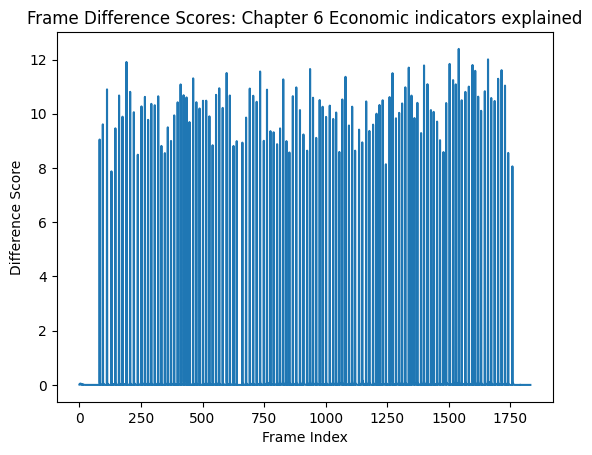

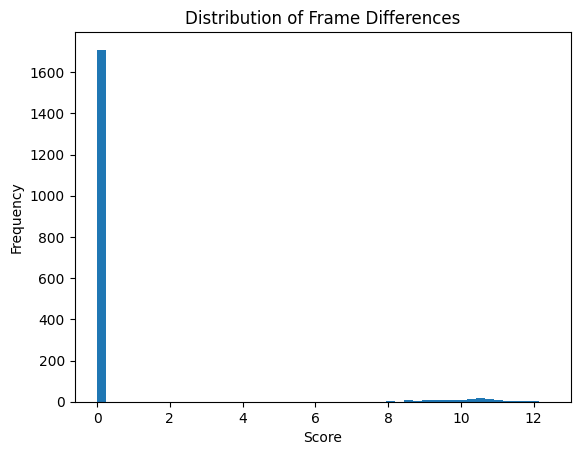

In [17]:
for video_path in videos_path:
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    print(f"\nAnalyzing: {video_name}")

    stat_array = get_scores(video_path)

    mean = np.mean(stat_array)
    median = np.median(stat_array)
    std = np.std(stat_array)
    max_val = np.max(stat_array)

    print(f"Mean: {mean:.2f}, Median: {median:.2f}, Std: {std:.2f}, Max: {max_val:.2f}")

    # Auto threshold
    mean_std_threshold = mean + 2 * std
    percentile_threshold = np.percentile(stat_array, 95)
    print(f"Suggested threshold using the mean and std is : {mean_std_threshold:.2f}")
    print(f"Suggested threshold using 95 percentile is : {percentile_threshold:.2f}")
    
    peaks, _ = find_peaks(stat_array, height=np.mean(stat_array) + 2*np.std(stat_array))
    print("Detected page changes:", len(peaks))

    plt.plot(stat_array)
    plt.title(f"Frame Difference Scores: {video_name}")
    plt.xlabel("Frame Index")
    plt.ylabel("Difference Score")
    plt.show()

    plt.hist(stat_array, bins=50)
    plt.title("Distribution of Frame Differences")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.show()
    

In [8]:
videos_path = glob("videos/*")
video_name = None
for video_path in videos_path:
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    print(f"working on video : {video_name}")
    if extract_pages(video_path,video_name) :
        print(f"Done extracting pages on video : {video_name}")
    else :
        print(f"failed to extract pages on video : {video_name} !!")

working on video : Chapter 6 Economic indicators explained


NameError: name 'threshold' is not defined